In [ ]:
!pip install requests beautifulsoup4 -q

In [ ]:
import os, re, time, sys
from datetime import datetime
import requests, pandas as pd
from bs4 import BeautifulSoup

APP_ID  = "b261483b"
APP_KEY = "b8a68b8f9dac6b7b38cb418c57f62859"


In [ ]:
COUNTRY = "in"
BASE = "https://api.adzuna.com/v1/api/jobs/{}/search/{}"

SEARCH_TERMS = ["data analyst", "business analyst", "data scientist", "data engineer",
                "power bi developer", "sql developer", "business intelligence",
                "analytics", "mis executive", "reporting analyst", "tableau developer",
                "python developer data", "data analytics associate", "research analyst"]
CITIES = ["Bengaluru", "Mumbai", "Delhi", "Gurgaon", "Noida",
          "Hyderabad", "Pune", "Chennai", "Kolkata", "Ahmedabad"]
CITY_QUERIES = ["data analyst", "business analyst", "data engineer"]

records = []


def clean_html(raw):
    """Descriptions come back with HTML tags inside. Strip them out."""
    text = BeautifulSoup(str(raw or ""), "html.parser").get_text(" ")
    return re.sub(r"\s+", " ", text).strip()


def fetch(term, page, where=None):
    """One API call, retried up to 3 times if the server is busy."""
    params = {"app_id": APP_ID, "app_key": APP_KEY, "results_per_page": 50,
              "what": term, "content-type": "application/json"}
    if where:
        params["where"] = where
    for attempt in range(3):
        r = requests.get(BASE.format(COUNTRY, page), params=params, timeout=30)
        if r.status_code == 200:
            return r.json().get("results", [])
        if r.status_code in (401, 403):
            raise SystemExit(f"Auth failed (HTTP {r.status_code}) - check your keys")
        time.sleep(2 ** attempt)
    return []


def parse(job, term):
    """The API returns nested JSON. Flatten one posting into one flat row."""
    loc = job.get("location") or {}
    area = loc.get("area") or []
    return {
        "job_id": job.get("id"), "title": job.get("title", ""),
        "company": (job.get("company") or {}).get("display_name", ""),
        "location_full": loc.get("display_name", ""),
        "region": area[1] if len(area) > 1 else "",
        "city": area[2] if len(area) > 2 else "",
        "description": clean_html(job.get("description")),
        "salary_min": job.get("salary_min"), "salary_max": job.get("salary_max"),
        "salary_is_predicted": job.get("salary_is_predicted"),
        "contract_time": job.get("contract_time", ""),
        "created": job.get("created", ""),
        "redirect_url": job.get("redirect_url", ""),

    }


def collect(term, pages, where=None):
    """Page through one search until it runs out of results."""
    for page in range(1, pages + 1):
        results = fetch(term, page, where)
        if not results:
            break
        records.extend(parse(j, term) for j in results)
        print(f"{where or 'national':12s} | {term:22s} | page {page:2d} | total {len(records)}", flush=True)
        time.sleep(1)


for term in SEARCH_TERMS:
    collect(term, 10)

for city in CITIES:
    for term in CITY_QUERIES:
        collect(term, 3, where=city)

df = pd.DataFrame(records)
before = len(df)
df = df.drop_duplicates("job_id").drop_duplicates(["title", "company", "location_full"])
df.to_csv("raw_job_postings.csv", index=False)

print(f"\nRows collected     : {before}")
print(f"Duplicates removed : {before - len(df)}")
print(f"Unique records     : {len(df)}")
print(f"With a salary      : {df['salary_min'].notna().sum()}")

national     | data analyst           | page  1 | total 50
national     | data analyst           | page  2 | total 100
national     | data analyst           | page  3 | total 150
national     | data analyst           | page  4 | total 200
national     | data analyst           | page  5 | total 250
national     | data analyst           | page  6 | total 300
national     | data analyst           | page  7 | total 350
national     | data analyst           | page  8 | total 400
national     | data analyst           | page  9 | total 450
national     | data analyst           | page 10 | total 500
national     | business analyst       | page  1 | total 550
national     | business analyst       | page  2 | total 600
national     | business analyst       | page  3 | total 650
national     | business analyst       | page  4 | total 700
national     | business analyst       | page  5 | total 750
national     | business analyst       | page  6 | total 800
national     | business analyst       | p

In [ ]:
from google.colab import files
files.download('raw_job_postings.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd

In [4]:
data=pd.read_csv('/content/raw_job_postings.csv')

In [64]:
data.head()

,job_id,title,company,location_full,region,city,description,salary_min,salary_max,salary_is_predicted,contract_time,created,redirect_url
0,5867038166,Data Analyst,Edwagon,"Bangalore, Karnataka",Karnataka,Bangalore,Company Description Edwagon is a growing organ...,NaN,NaN,0,full_time,2026-09-02T16:44:13Z,https://www.adzuna.in/land/ad/5867038166?se=mE...
1,5864442719,Data Analyst,HCLTech,"Hyderabad, Telangana",Telangana,Hyderabad,HACKATHON - 29th Aug 26 - Planning for 2 skill...,NaN,NaN,0,NaN,2026-09-01T16:23:16Z,https://www.adzuna.in/land/ad/5864442719?se=mE...
2,5864442622,Data Analyst,Quilytics,"Mumbai, Maharashtra",Maharashtra,Mumbai,Company Description Quilytics is a quality-fir...,NaN,NaN,0,full_time,2026-09-01T16:23:15Z,https://www.adzuna.in/land/ad/5864442622?se=mE...
3,5868794860,Data Analyst,Tata Consultancy Services,India,NaN,NaN,Greetings from TATA CONSULTANCY SERVICES! WALK...,NaN,NaN,0,NaN,2026-09-03T16:51:20Z,https://www.adzuna.in/land/ad/5868794860?se=mE...
4,5864432449,Data Analyst,EXL,"Chennai, Tamil Nadu",Tamil Nadu,Chennai,Bachelor’s degree with minimum 6 years’ experi...,NaN,NaN,0,NaN,2026-09-01T16:21:54Z,https://www.adzuna.in/land/ad/5864432449?se=mE...


In [5]:
data.shape

(6967, 13)

In [6]:
print("missing_max_salary_count:",data['salary_max'].isna().sum())

missing_max_salary_count: 5604


In [7]:
print("missing_min_salary_count:",data['salary_min'].isna().sum())

missing_min_salary_count: 5604


5,604 missing, so 1,363 have a salary. That's 19.6% coverage.
it also shows four out of five Indian analytics postings don't disclose pay

In [8]:
print(data["city"].value_counts())
print(data["city"].nunique())
print()
print("rows with no city:", data["city"].isna().sum())

city
Bangalore      1166
Hyderabad       708
Mumbai          683
Pune            564
Chennai         505
               ... 
Sonipat           1
Cuttack           1
Ranchi            1
North Delhi       1
West Delhi        1
Name: count, Length: 96, dtype: int64
96

rows with no city: 1687


LOCATION CLEANING - group scattered city names into hiring markets
 ------------------------------------------------------------
 problem 1: the same market appears under many names Gurgaon, Noida ,Ghaziabad are all Delhi NCR.
 Bangalore and Bengaluru are one city, two spellings.

 Problem 2: 1,687 postings have no city recorded at all - Adzuna
 only stored "India" for them.


In [9]:
 #Mapping
 # Tier 1: government HRA "X category" cities
Tier_1 = {
    "bengaluru": "Bengaluru", "bangalore": "Bengaluru",
    "mumbai": "Mumbai", "navi mumbai": "Mumbai", "thane": "Mumbai",
    "delhi": "Delhi NCR", "gurgaon": "Delhi NCR", "gurugram": "Delhi NCR",
    "noida": "Delhi NCR", "faridabad": "Delhi NCR", "ghaziabad": "Delhi NCR",
    "hyderabad": "Hyderabad", "secunderabad": "Hyderabad",
    "pune": "Pune", "chennai": "Chennai", "kolkata": "Kolkata",
    "ahmedabad": "Ahmedabad", "gandhinagar": "Ahmedabad",
    "surat": "Surat",
}

# Tier 2: smaller hubs — enough for posting counts, too few for salary medians
Tier_2 = {
    "chandigarh": "Chandigarh", "mohali": "Chandigarh",
    "jaipur": "Jaipur",
    "kochi": "Kochi", "ernakulam": "Kochi", "thiruvananthapuram": "Kochi",
    "coimbatore": "Coimbatore",
    "vadodara": "Vadodara",
    "indore": "Indore",
    "lucknow": "Lucknow",
    "nagpur": "Nagpur",
}


Combine all three location columns into one searchable text field.

This is the fix for Problem 2 - a posting with an empty "city" can
still be placed from "location_full" or "region".

  fillna("")   turns missing values into blank text, so joining works

 .str.lower() makes matching case-insensitive

In [10]:
data["location_text"] = (
    data["city"].fillna("") + " " +
    data["location_full"].fillna("") + " " +
    data["region"].fillna("")
).str.lower()

In [11]:
#Anything we can't place in tier_1 and tier_2
data["city_wise"] = "Unknown"
data["city_tier"] = "Unknown"

In [12]:
# go through both dictionaries, tagging the metro AND its tier together
for mapping, tier in [(Tier_1, "Tier 1"), (Tier_2, "Tier 2")]:
    for keyword, metro_name in mapping.items():
        found = data["location_text"].str.contains(keyword, na=False)
        unassigned = data["city_wise"] == "Unknown"
        data.loc[found & unassigned, "city_wise"] = metro_name
        data.loc[found & unassigned, "city_tier"] = tier


In [13]:
print(data["city_wise"].value_counts())
print()
print(data["city_tier"].value_counts())

city_wise
Unknown       1569
Bengaluru     1167
Delhi NCR     1042
Mumbai         741
Hyderabad      708
Pune           564
Chennai        505
Ahmedabad      281
Kolkata        206
Jaipur          37
Kochi           29
Vadodara        28
Coimbatore      24
Chandigarh      21
Indore          20
Lucknow          9
Nagpur           8
Surat            8
Name: count, dtype: int64

city_tier
Tier 1     5222
Unknown    1569
Tier 2      176
Name: count, dtype: int64


In [14]:
#Join title and description into one column,fillna replace the missing value with empty text
data["text"]=(data['description'].fillna("")+""+data['title'].fillna("")).str.lower()

In [15]:
data["text"].head()

,text
0,company description edwagon is a growing organ...
1,hackathon - 29th aug 26 - planning for 2 skill...
2,company description quilytics is a quality-fir...
3,greetings from tata consultancy services! walk...
4,bachelor’s degree with minimum 6 years’ experi...


In [16]:
SKILLS = {
    "sql":"sql",
    "python":"python",
    "excel": "excel",
    "power_bi":"power bi|powerbi|dax",
    "tableau": "tableau",
    "cloud":"aws|azure|gcp|snowflake|databricks|cloud",
    "big_data":"spark|hadoop|hive|kafka",
    "machine_learning": "machine learning|deep learning|tensorflow",
    "etl":"etl|airflow|dbt|data pipeline",
    "statistics":"statistic|regression|hypothesis",
    "visualisation":"dashboard|visuali|looker|qlik",
}

In [17]:
# one new column per skill: 1 if the posting mentions it, 0 if not
for skill, pattern in SKILLS.items():
    data["skill_" + skill] = data["text"].str.contains(pattern, na=False).astype(int)



In [18]:
# collect the skill columns BEFORE adding the total, so the total isn't in the list
skill_cols = [c for c in data.columns if c.startswith("skill_")]

# how many skills does each posting mention?
data["skill_count"] = data[skill_cols].sum(axis=1)

print(data[skill_cols].sum().sort_values(ascending=False))
print()
print("average skills per posting:", data["skill_count"].mean().round(2))

skill_cloud               1239
skill_sql                 1088
skill_etl                  741
skill_visualisation        714
skill_python               638
skill_excel                554
skill_power_bi             452
skill_big_data             333
skill_machine_learning     262
skill_statistics           232
skill_tableau              200
dtype: int64

average skills per posting: 0.93


In [19]:
print(data["skill_count"].value_counts().sort_index())

skill_count
0    3663
1    1679
2     762
3     425
4     274
5     121
6      29
7      12
8       2
Name: count, dtype: int64


In [20]:
print(data["title"].value_counts().head(30))

title
Business Analyst                                      318
Data Engineer                                         258
Data Analyst                                          208
Data Scientist                                        177
Senior Data Engineer                                  118
Senior Data Analyst                                    56
MIS Executive                                          47
Power BI Developer                                     44
Senior Business Analyst                                40
Azure Data Engineer                                    39
Analytics Manager                                      37
SQL Developer                                          36
Research Analyst                                       32
Lead Data Engineer                                     30
Senior Data Scientist                                  27
AWS Data Engineer                                      23
GCP Data Engineer                                      22
Python D

In [21]:
def get_seniority(title):
    t = title.lower()
    if "head" in t or "director" in t or "vp" in t or "chief" in t:
        return "Leadership"
    if "lead" in t or "manager" in t or "architect" in t:
        return "Lead/Manager"
    if "senior" in t or "sr." in t or "sr " in t:
        return "Senior"
    if "junior" in t or "intern" in t or "trainee" in t or "fresher" in t or "associate" in t:
        return "Entry"
    return "Mid"


def get_role_family(title):
    t = title.lower()
    if "data scien" in t or "machine learning" in t:
        return "Data Science / ML"
    if "data engineer" in t or "etl" in t or "big data" in t:
        return "Data Engineering"
    if "business intelligence" in t or "power bi" in t or "tableau" in t or "mis" in t:
        return "BI / Reporting"
    if "business analyst" in t:
        return "Business Analysis"
    if "data analyst" in t or "analytics" in t or "analyst" in t or "sql" in t:
        return "Data Analysis"
    return "Other"


data["seniority"] = data["title"].apply(get_seniority)
data["role_family"] = data["title"].apply(get_role_family)

data["salary_min"] = pd.to_numeric(data["salary_min"], errors="coerce")
data["salary_max"] = pd.to_numeric(data["salary_max"], errors="coerce")
data["salary"] = data[["salary_min", "salary_max"]].mean(axis=1)

print(data["seniority"].value_counts())
print()
print(data["role_family"].value_counts())

seniority
Mid             4206
Senior          1251
Lead/Manager    1063
Entry            264
Leadership       183
Name: count, dtype: int64

role_family
Other                2166
Data Analysis        1890
Data Engineering     1069
Business Analysis     767
BI / Reporting        646
Data Science / ML     429
Name: count, dtype: int64


In [22]:
# ============================================================
# SKILL SALARY PREMIUM - the main finding of the project
# ============================================================
# For each skill, split postings into two groups:
#   - those that mention the skill
#   - those that don't
# Compare the median salary of each group. The difference is
# the "premium" that skill carries.
#
# Only postings with a salary are used (about 20% of the data),
# because .dropna() removes the rest from each group.

rows = []

for col in skill_cols:
    # postings that mention this skill, and their salaries
    with_skill = data.loc[data[col] == 1, "salary"].dropna()

    # postings that do not mention it
    without = data.loc[data[col] == 0, "salary"].dropna()

    rows.append({
        "skill": col.replace("skill_", ""),      # tidy name for the chart
        "postings": data[col].sum(),             # how many mention it
        "median_with": with_skill.median(),      # typical pay when present
        "median_without": without.median(),      # typical pay when absent
        # percentage difference between the two medians
        "premium_pct": round((with_skill.median() / without.median() - 1) * 100, 1),
    })

# turn the list of results into a table, highest premium first
skill_summary = pd.DataFrame(rows).sort_values("premium_pct", ascending=False)
print(skill_summary.to_string(index=False))

           skill  postings  median_with  median_without  premium_pct
machine_learning       262    1650000.0        900000.0         83.3
             etl       741    1300000.0        850000.0         52.9
           cloud      1239    1275000.0        850000.0         50.0
        big_data       333    1300000.0        900000.0         44.4
      statistics       232    1250000.0        900000.0         38.9
          python       638    1250000.0        900000.0         38.9
             sql      1088    1100000.0        850000.0         29.4
        power_bi       452    1100000.0        900000.0         22.2
         tableau       200    1000000.0        950000.0          5.3
   visualisation       714     906400.0        950000.0         -4.6
           excel       554     700000.0       1000000.0        -30.0


"262 postings mention machine learning. Among those with a salary, the median is ₹16.5 lakh. Among postings that don't mention ML, the median is ₹9 lakh. That's an 83.3% difference."

In [23]:
# ============================================================
# EXPORT THE CLEANED DATASET
# ============================================================
# This CSV is one of your required deliverables. It is also what
# Power BI will load later.

data.to_csv("cleaned_job_postings.csv", index=False)
print("saved:", data.shape[0], "rows x", data.shape[1], "columns")

saved: 6967 rows x 32 columns


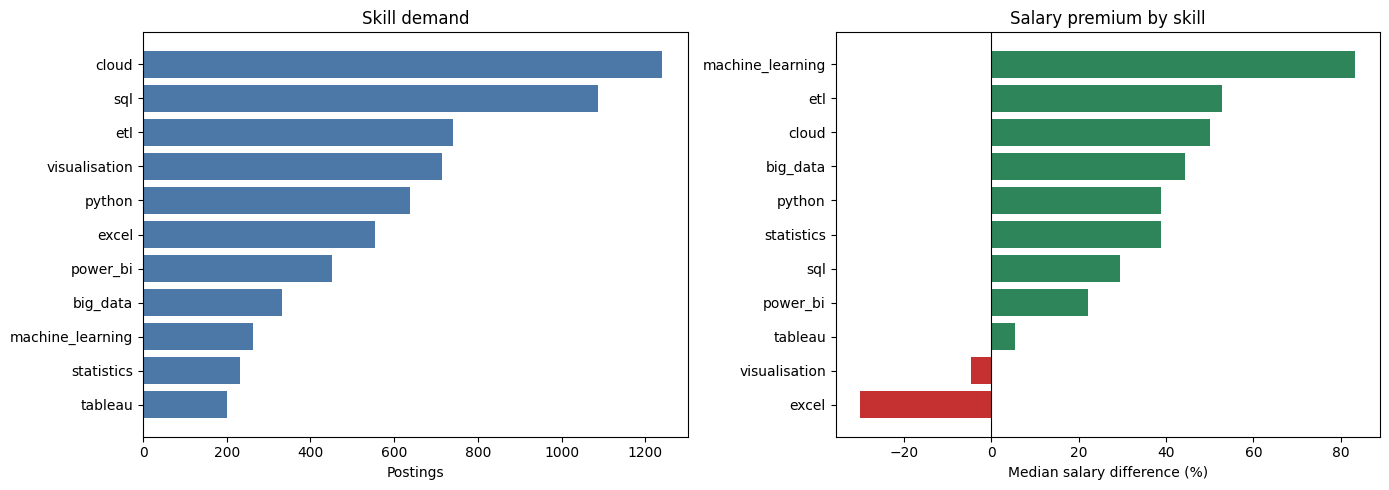

In [24]:
# ============================================================
# CHART 1 - skill demand vs salary premium
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: how often each skill is mentioned
demand = skill_summary.sort_values("postings")
axes[0].barh(demand["skill"], demand["postings"], color="#4c78a8")
axes[0].set_title("Skill demand")
axes[0].set_xlabel("Postings")

# RIGHT: what each skill is worth
# red for negative premiums, green for positive
premium = skill_summary.sort_values("premium_pct")
colors = ["#c53030" if v < 0 else "#2f855a" for v in premium["premium_pct"]]
axes[1].barh(premium["skill"], premium["premium_pct"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)   # the zero line
axes[1].set_title("Salary premium by skill")
axes[1].set_xlabel("Median salary difference (%)")

plt.tight_layout()
plt.savefig("chart_skill_premium.png", dpi=150, bbox_inches="tight")
plt.show()

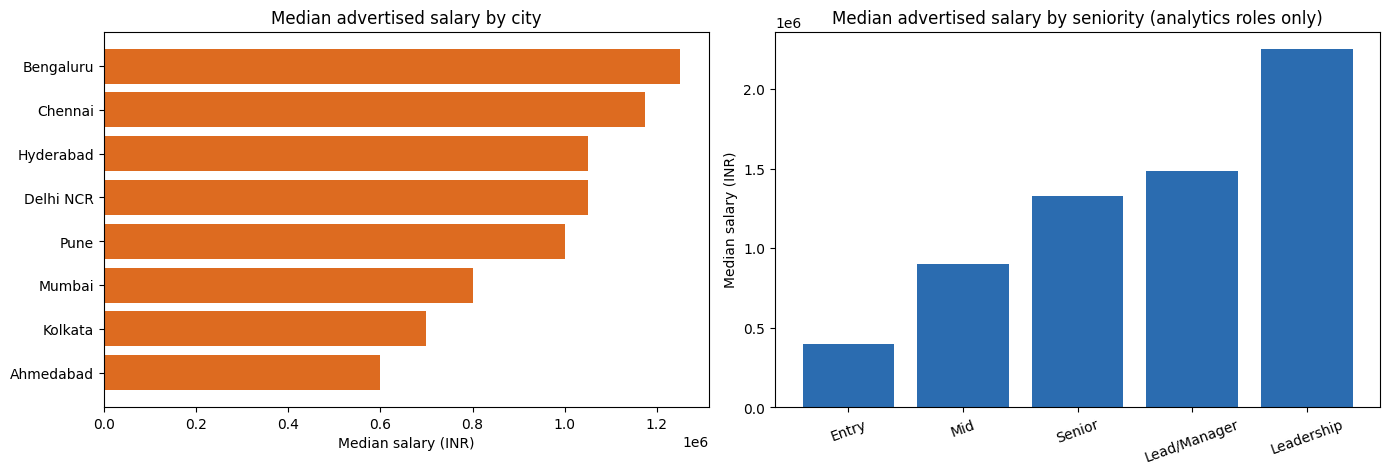

           count     median
city_wise                  
Ahmedabad     87   600000.0
Kolkata       43   700000.0
Mumbai       214   800000.0
Pune         139  1000000.0
Delhi NCR    200  1050000.0
Hyderabad     78  1050000.0
Chennai       74  1175000.0
Bengaluru    223  1250000.0

seniority
Entry            400000.0
Mid              900000.0
Senior          1325000.0
Lead/Manager    1487500.0
Leadership      2250000.0
Name: salary, dtype: float64


In [28]:
# ============================================================
# CHART 2 - what the market pays by city and by seniority
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- LEFT: median salary by city --------------------------------
# only cities we could identify, and only those with at least 30
# salaried postings so the median is reliable
geo = data[data["city_wise"] != "Unknown"]
city_pay = geo.groupby("city_wise")["salary"].agg(["count", "median"])
city_pay = city_pay[city_pay["count"] >= 30].sort_values("median")

axes[0].barh(city_pay.index, city_pay["median"], color="#dd6b20")
axes[0].set_title("Median advertised salary by city")
axes[0].set_xlabel("Median salary (INR)")

# ---- RIGHT: median salary by seniority --------------------------
# Our search terms pulled in some non-analytics jobs - Sales Manager,
# Relationship Manager, Assistant Manager. Their titles contain
# "manager", so they landed in Lead/Manager and dragged its median
# down. Those roles sit in role_family "Other", so we exclude Other
# here and compare analytics roles only.
core = data[data["role_family"] != "Other"]

order = ["Entry", "Mid", "Senior", "Lead/Manager", "Leadership"]
sen_pay = core.groupby("seniority")["salary"].median().reindex(order)

axes[1].bar(sen_pay.index, sen_pay.values, color="#2b6cb0")
axes[1].set_title("Median advertised salary by seniority (analytics roles only)")
axes[1].set_ylabel("Median salary (INR)")
plt.setp(axes[1].get_xticklabels(), rotation=20)

plt.tight_layout()
plt.savefig("chart_city_seniority.png", dpi=150, bbox_inches="tight")
plt.show()

print(city_pay)
print()
print(sen_pay)

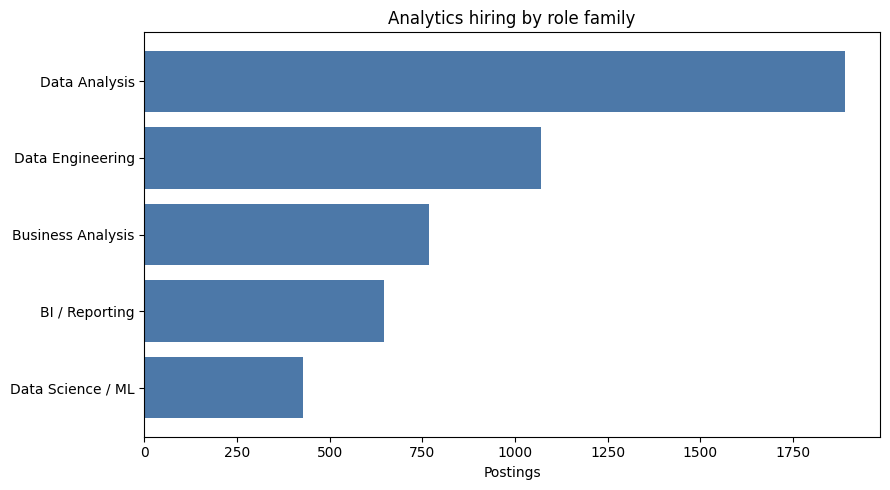

role_family
Data Analysis        1890
Data Engineering     1069
Business Analysis     767
BI / Reporting        646
Data Science / ML     429
Name: count, dtype: int64


In [29]:
# ============================================================
# CHART - current demand by role family
# ============================================================
# A snapshot of what the market is hiring for, not a time trend -
# the data covers only a few weeks, too short to show change.

role_counts = data[data["role_family"] != "Other"]["role_family"].value_counts()

plt.figure(figsize=(9, 5))
plt.barh(role_counts.index[::-1], role_counts.values[::-1], color="#4c78a8")
plt.title("Analytics hiring by role family")
plt.xlabel("Postings")
plt.tight_layout()
plt.savefig("chart_role_demand.png", dpi=150, bbox_inches="tight")
plt.show()

print(role_counts)

"By raw posting volume, Data Analysis dominates Indian hiring. But Data Science / ML, despite the fewest postings, commands the highest salary premium — suggesting demand is real and under-supplied, not absent."

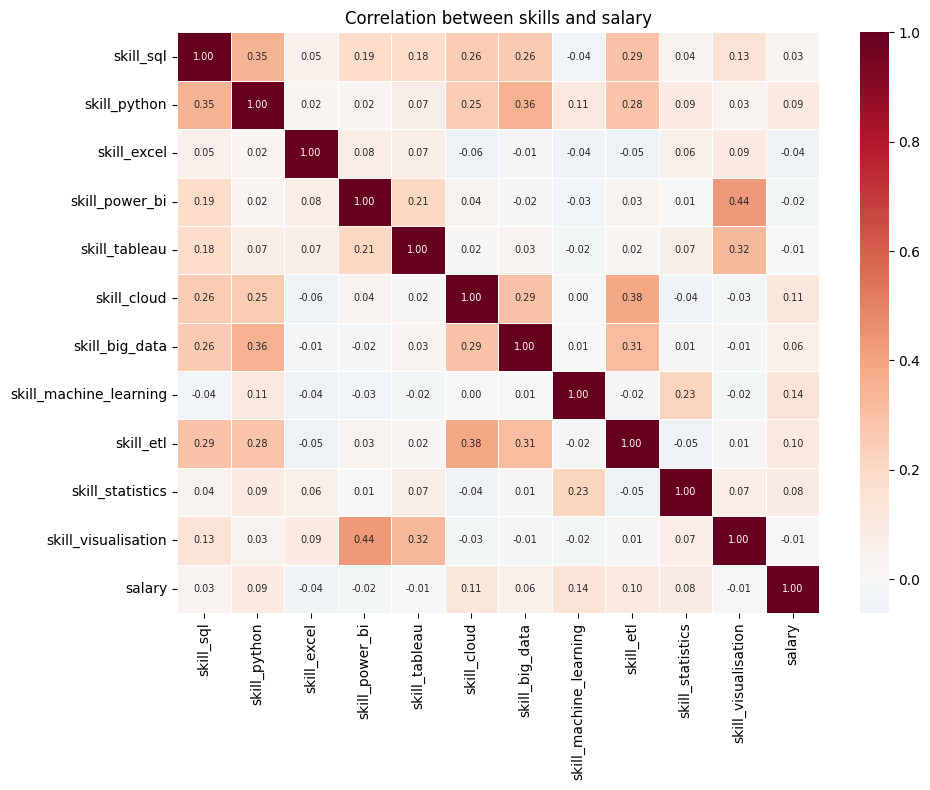

In [30]:
# ============================================================
# CORRELATION HEATMAP - which skills appear together, and with pay
# ============================================================
# If skills cluster together, then a "skill premium" is really a
# premium on a whole profile, not one tool learned in isolation.
import seaborn as sns

corr = data[skill_cols + ["salary"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=0.4)
plt.title("Correlation between skills and salary")
plt.tight_layout()
plt.savefig("chart_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

Among all the skills, machine learning has the strongest positive relationship with salary — 0.14, the highest in the row. This means postings mentioning machine learning tend to have somewhat higher salaries than postings that don't.

Among all the skills, Power BI with visualization has the highest positive correlationship. That means the post that is posted for any role combines Power BI has also tends to have visualization skills.

In [34]:
# ============================================================
# MODEL - find the best number of clusters, then build it
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# only postings that mention at least one skill - the rest have
# no skill signal and would form one meaningless empty cluster
cluster_data = data[data["skill_count"] >= 1].copy()
print(f"Clustering {len(cluster_data)} of {len(data)} postings that mention a skill")

# put every skill flag on the same scale before clustering
X = StandardScaler().fit_transform(cluster_data[skill_cols])

# test k from 2 to 8, keep whichever gives the tightest, most
# separated groups (highest silhouette score)
scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    scores.append({"k": k, "silhouette": silhouette_score(X, labels)})

k_scores = pd.DataFrame(scores)
best_k = int(k_scores.loc[k_scores["silhouette"].idxmax(), "k"])
print(k_scores)
print(f"\nBest k = {best_k}")

# build the final clustering using that best k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_data["cluster"] = kmeans.fit_predict(X)

# describe each cluster: size, pay, defining skills
profile = cluster_data.groupby("cluster").agg(
    postings=("job_id", "count"),
    median_salary=("salary", "median"),
    avg_skills=("skill_count", "mean"),
).round(0)

for c in profile.index:
    top3 = cluster_data[cluster_data["cluster"] == c][skill_cols].mean().sort_values(ascending=False).head(3)
    profile.loc[c, "top_skills"] = ", ".join(top3.index.str.replace("skill_", ""))

print(profile)

Clustering 3304 of 6967 postings that mention a skill
   k  silhouette
0  2    0.165659
1  3    0.208178
2  4    0.261921
3  5    0.236831
4  6    0.281177
5  7    0.334058
6  8    0.379678

Best k = 8
         postings  median_salary  avg_skills  \
cluster                                        
0             623      1090000.0         2.0   
1             208      1275000.0         2.0   
2             813      1450000.0         1.0   
3             534      1000000.0         2.0   
4             300      1300000.0         4.0   
5             429       650000.0         1.0   
6             197      1500000.0         2.0   
7             200      1000000.0         4.0   

                                   top_skills  
cluster                                        
0                             sql, cloud, etl  
1        statistics, machine_learning, python  
2                          cloud, etl, python  
3                visualisation, power_bi, sql  
4                        big_

Cluster 0 — defined by SQL, Cloud and ETL — contains 623 postings with a median salary of ₹10.9 lakh, averaging 2 detected skills per posting."

In [38]:
# ============================================================
# ADD CLUSTER NAMES, THEN EXPORT FOR POWER BI
# ============================================================
cluster_names = {
    0: "Cloud & SQL Engineering",
    1: "Statistics & ML Analytics",
    2: "Cloud Data Pipeline",
    3: "Power BI Reporting",
    4: "Big Data Engineering",
    5: "Standard MIS / Excel Reporting",
    6: "Advanced ML Engineering",
    7: "Tableau Reporting",
}
data["segment"] = cluster_data["cluster"].map(cluster_names)
data["segment"] = data["segment"].fillna("No skill listed")

print(data["segment"].value_counts())
print()

# save the full dataset - this is what Power BI will load
data.to_csv("powerbi_dataset_job_posting.csv", index=False)
print("saved:", data.shape[0], "rows x", data.shape[1], "columns")

segment
No skill listed                   3663
Cloud Data Pipeline                813
Cloud & SQL Engineering            623
Power BI Reporting                 534
Standard MIS / Excel Reporting     429
Big Data Engineering               300
Statistics & ML Analytics          208
Tableau Reporting                  200
Advanced ML Engineering            197
Name: count, dtype: int64

saved: 6967 rows x 33 columns


In [40]:
from google.colab import files
files.download("powerbi_dataset_job_posting.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>